In [5]:
import sqlite3
#it allow python to connect ,create and query sqlite database
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [6]:
df=pd.read_csv('/content/student_performance.csv')
df.head(3)

,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023


In [9]:
print("no of rows:",df.shape[0])
print("no of columns:",df.shape[1])

no of rows: 30
no of columns: 13


In [9]:
#sqlite3.connect()-create or opens a database file
#conn - connection object (our link to the database)
#cursor-tool that executes SQL  commands
#df.to_sql()- writes the dataframes as a database table
conn=sqlite3.connect('college.db')
cursor=conn.cursor()
df.to_sql(
    'students',
    conn,
    if_exists='replace',
    index=False
)
# to_sql() automatically
# 1.create the table with correct columns
cursor.execute("SELECT count(*) from students")
count=cursor.fetchone()[0]
#.fetchone() retrieves the first result row
print("no of rows:",count)

no of rows: 30


In [10]:
cursor.execute("SELECT * from students")
result=cursor.fetchall()
print(result)
print("-"*1000)
cursor.execute("SELECT * from students")
result2=cursor.fetchone()
print(result2)

[(1001, 'Aarav Sharma', 19, 'Male', 'Computer Science', 2, 85, 78, 72, 91, 92, 'Mumbai', 2023), (1002, 'Priya Patel', 20, 'Female', 'Computer Science', 2, 76, 82, 88, 79, 87, 'Ahmedabad', 2023), (1003, 'Rohit Verma', 19, 'Male', 'Electronics', 2, 65, 74, 61, 55, 78, 'Delhi', 2023), (1004, 'Sneha Reddy', 20, 'Female', 'Mechanical', 2, 70, 80, 75, 48, 95, 'Hyderabad', 2023), (1005, 'Arjun Nair', 19, 'Male', 'Computer Science', 2, 92, 88, 81, 95, 90, 'Kochi', 2023), (1006, 'Meera Joshi', 20, 'Female', 'Electronics', 2, 58, 66, 70, 52, 72, 'Pune', 2023), (1007, 'Kiran Kumar', 21, 'Male', 'Civil', 2, 73, 69, 65, 40, 85, 'Bangalore', 2023), (1008, 'Divya Singh', 19, 'Female', 'Computer Science', 2, 88, 91, 84, 93, 96, 'Lucknow', 2023), (1009, 'Rahul Mishra', 20, 'Male', 'Mechanical', 2, 62, 71, 58, 45, 68, 'Varanasi', 2023), (1010, 'Ananya Das', 19, 'Female', 'Computer Science', 2, 95, 89, 90, 97, 98, 'Kolkata', 2023), (1011, 'Vikram Iyer', 20, 'Male', 'Electronics', 2, 80, 75, 68, 72, 83, '

In [11]:
cursor.execute("PRAGMA table_info(students)")

columns_info = cursor.fetchall()

print("Table Structure of 'students':")
print(f"{'Column Name':<25}{'Data Types':<12}")
print("-" * 30)

for column in columns_info:
    print(f"{column[1]:<25}{column[2]:<12}")

Table Structure of 'students':
Column Name              Data Types  
------------------------------
student_id               INTEGER     
name                     TEXT        
age                      INTEGER     
gender                   TEXT        
department               TEXT        
semester                 INTEGER     
math_score               INTEGER     
science_score            INTEGER     
english_score            INTEGER     
programming_score        INTEGER     
attendance_percentage    INTEGER     
city                     TEXT        
admission_year           INTEGER     


In [13]:
def run_query(sql,description=""):
  if description:
    print(f"\n{'='*55}")
    print(f"{description}")
    print(f"{'-'*55}")
  result=pd.read_sql_query(sql,conn)
  return result

In [14]:
query1="""
select student_id,name,department,math_score,attendance_percentage
from students
limit 10
"""
result1=run_query(query1,"Query 1: First 10 Students(SELECT + LIMIT)")
print(result1)




Query 1: First 10 Students(SELECT + LIMIT)
-------------------------------------------------------
   student_id          name        department  math_score  \
0        1001  Aarav Sharma  Computer Science          85   
1        1002   Priya Patel  Computer Science          76   
2        1003   Rohit Verma       Electronics          65   
3        1004   Sneha Reddy        Mechanical          70   
4        1005    Arjun Nair  Computer Science          92   
5        1006   Meera Joshi       Electronics          58   
6        1007   Kiran Kumar             Civil          73   
7        1008   Divya Singh  Computer Science          88   
8        1009  Rahul Mishra        Mechanical          62   
9        1010    Ananya Das  Computer Science          95   

   attendance_percentage  
0                     92  
1                     87  
2                     78  
3                     95  
4                     90  
5                     72  
6                     85  
7           

In [15]:
query1="""
select student_id,name,department,math_score,attendance_percentage
from students
limit 10 offset 25
"""
result1=run_query(query1,"Query 1:  last 5 Students(SELECT + LIMIT)")
print(result1)


Query 1:  last 5 Students(SELECT + LIMIT)
-------------------------------------------------------
   student_id            name        department  math_score  \
0        1026      Rekha Nair       Electronics          72   
1        1027   Gaurav Shukla  Computer Science          84   
2        1028   Sunita Pillai             Civil          60   
3        1029      Nitin Jain        Mechanical          75   
4        1030  Akanksha Yadav  Computer Science          91   

   attendance_percentage  
0                     82  
1                     87  
2                     73  
3                     84  
4                     95  


In [16]:
query1 = """
SELECT student_id, name, department, math_score, attendance_percentage
FROM students
ORDER BY student_id DESC
LIMIT 5
"""
result1 = run_query(query1, "Query 1: Last 5 Students")
print(result1)


Query 1: Last 5 Students
-------------------------------------------------------
   student_id            name        department  math_score  \
0        1030  Akanksha Yadav  Computer Science          91   
1        1029      Nitin Jain        Mechanical          75   
2        1028   Sunita Pillai             Civil          60   
3        1027   Gaurav Shukla  Computer Science          84   
4        1026      Rekha Nair       Electronics          72   

   attendance_percentage  
0                     95  
1                     84  
2                     73  
3                     87  
4                     82  


In [17]:
query1 = """
SELECT student_id, name, science_score, math_score, english_score,programming_score
FROM students
ORDER BY student_id DESC
LIMIT 5
"""

result1 = run_query(query1, "Query 1: Last 5 Students")

print(result1)


Query 1: Last 5 Students
-------------------------------------------------------
   student_id            name  science_score  math_score  english_score  \
0        1030  Akanksha Yadav             93          91             87   
1        1029      Nitin Jain             76          75             70   
2        1028   Sunita Pillai             65          60             68   
3        1027   Gaurav Shukla             79          84             75   
4        1026      Rekha Nair             77          72             73   

   programming_score  
0                 94  
1                 50  
2                 39  
3                 87  
4                 63  


In [18]:
query1 = """
SELECT student_id, name, science_score, math_score, english_score, programming_score
FROM students
WHERE student_id BETWEEN 1026 AND 1030
ORDER BY student_id ASC
"""
result1 = run_query(query1, "Query 1: Last 5 Students")

print(result1)


Query 1: Last 5 Students
-------------------------------------------------------
   student_id            name  science_score  math_score  english_score  \
0        1026      Rekha Nair             77          72             73   
1        1027   Gaurav Shukla             79          84             75   
2        1028   Sunita Pillai             65          60             68   
3        1029      Nitin Jain             76          75             70   
4        1030  Akanksha Yadav             93          91             87   

   programming_score  
0                 63  
1                 87  
2                 39  
3                 50  
4                 94  


In [19]:
query2 = """
SELECT  name,math_score,department
FROM students
ORDER BY math_score ASC
limit 5
"""
result1 = run_query(query2, "Query 1: first 5 Students")

print(result1)


Query 1: first 5 Students
-------------------------------------------------------
            name  math_score   department
0   Manoj Pandey          56        Civil
1    Meera Joshi          58  Electronics
2  Sunita Pillai          60        Civil
3   Sanjay Dubey          61        Civil
4   Rahul Mishra          62   Mechanical


In [54]:
query2 = """
SELECT  name,math_score,department
FROM students
where math_score>50 and math_score<70
ORDER BY math_score ASC
"""

result1 = run_query(query2, "Query 1: Students maths scorce")

print(result1)


Query 1: first 5 Students
-------------------------------------------------------
             name  math_score   department
0    Manoj Pandey          56        Civil
1     Meera Joshi          58  Electronics
2   Sunita Pillai          60        Civil
3    Sanjay Dubey          61        Civil
4    Rahul Mishra          62   Mechanical
5   Harish Pillai          64  Electronics
6     Rohit Verma          65  Electronics
7     Pooja Gupta          67        Civil
8  Deepak Chauhan          68   Mechanical


In [55]:
query2 = """
SELECT  name, department,programming_score
FROM students
WHERE programming_score BETWEEN 50 AND 75
ORDER BY programming_score ASC
"""
result2 = run_query(query2, "Query 2: Programming score Between 50 and 75:")

print(result2)


Query 2: Programming score Between 50 and 75:
-------------------------------------------------------
            name   department  programming_score
0     Nitin Jain   Mechanical                 50
1  Kavya Nambiar   Mechanical                 51
2    Meera Joshi  Electronics                 52
3  Preeti Saxena   Mechanical                 53
4    Rohit Verma  Electronics                 55
5  Harish Pillai  Electronics                 58
6     Rekha Nair  Electronics                 63
7   Ritu Agarwal  Electronics                 69
8    Vikram Iyer  Electronics                 72


In [60]:
query3="""
select name,math_score,science_score,programming_score,attendance_percentage
from students
where department='Computer Science'
order by programming_score desc
"""
result3=run_query(query3,"Query 3: Computer Science Students")
print(result3)


Query 3: Computer Science Students
-------------------------------------------------------
              name  math_score  science_score  programming_score  \
0       Ananya Das          95             89                 97   
1      Tanvi Mehta          93             90                 96   
2       Arjun Nair          92             88                 95   
3   Akanksha Yadav          91             93                 94   
4      Divya Singh          88             91                 93   
5   Swati Kulkarni          90             87                 92   
6     Aarav Sharma          85             78                 91   
7        Amit Bose          86             82                 89   
8       Suresh Rao          83             86                 88   
9    Gaurav Shukla          84             79                 87   
10    Nisha Kapoor          79             84                 83   
11     Priya Patel          76             82                 79   
12     Ajay Tiwari      

In [63]:
query3="""
select name,department,math_score,science_score,programming_score
from students
where department in ('Computer Science','Electronics',	'Mechanical')
order by programming_score desc
limit 1
"""
result3=run_query(query3,"Query 3: Top programming scored Student")
print(result3)


Query 3: Top programming scored Student
-------------------------------------------------------
         name        department  math_score  science_score  programming_score
0  Ananya Das  Computer Science          95             89                 97


In [65]:
query4="""
SELECT name,department,attendance_percentage
FROM students
WHERE attendance_percentage>90
AND department!='Civil'
ORDER BY attendance_percentage DESC
"""
result4=run_query(query4,"Query 4: Students with attendance greater than 90")
print(result4)


Query 4: Students with attendance greater than 90
-------------------------------------------------------
             name        department  attendance_percentage
0      Ananya Das  Computer Science                     98
1     Tanvi Mehta  Computer Science                     97
2     Divya Singh  Computer Science                     96
3     Sneha Reddy        Mechanical                     95
4  Akanksha Yadav  Computer Science                     95
5  Swati Kulkarni  Computer Science                     94
6    Ritu Agarwal       Electronics                     93
7    Aarav Sharma  Computer Science                     92
8   Kavya Nambiar        Mechanical                     91
9       Amit Bose  Computer Science                     91


In [67]:
query4="""
SELECT name,department,attendance_percentage
FROM students
WHERE attendance_percentage
AND department!='Civil'
ORDER BY attendance_percentage DESC
"""
result4=run_query(query4,"Query 4: Students with attendance BETWEEN 50 AND ")
print(result4)


Query 4: Students with attendance BETWEEN 50 AND 
-------------------------------------------------------
              name        department  attendance_percentage
0       Ananya Das  Computer Science                     98
1      Tanvi Mehta  Computer Science                     97
2      Divya Singh  Computer Science                     96
3   Swati Kulkarni  Computer Science                     94
4     Ritu Agarwal       Electronics                     93
5     Aarav Sharma  Computer Science                     92
6    Kavya Nambiar        Mechanical                     91
7        Amit Bose  Computer Science                     91
8     Nisha Kapoor  Computer Science                     89
9       Suresh Rao  Computer Science                     88
10     Priya Patel  Computer Science                     87
11   Gaurav Shukla  Computer Science                     87
12   Preeti Saxena        Mechanical                     86
13      Nitin Jain        Mechanical                 

In [26]:
dept_data={
    'dept_code':['CS','EC','ME','CE'],
    'dept_name':['Computer Science','Electronics','Mechanical','Civil'],
    'Hod_name':['Dr. A','Dr. B','Dr. C','Dr. D'],
    'established':[1985,1988,1972,1965],
    'intake':[60,60,60,60]
}
dept_df=pd.DataFrame(dept_data)
dept_df.to_sql('departments',conn,if_exists='replace',index=False)
print("created 'department table")
print(dept_df.to_string(index=False))
dept_map={
    'Computer Science':'CS',
    'Electronics'     :'EC',
    'Mechanical'      :'ME',
    'Civil'           :'CE'
}
df['department']=df['department'].map(dept_map)
df.to_sql('students',conn,if_exists='replace',index=False)
print("updated students table")
print(df.head())

created 'department table
dept_code        dept_name Hod_name  established  intake
       CS Computer Science    Dr. A         1985      60
       EC      Electronics    Dr. B         1988      60
       ME       Mechanical    Dr. C         1972      60
       CE            Civil    Dr. D         1965      60
updated students table
   student_id          name  age  gender department  semester  math_score  \
0        1001  Aarav Sharma   19    Male         CS         2          85   
1        1002   Priya Patel   20  Female         CS         2          76   
2        1003   Rohit Verma   19    Male         EC         2          65   
3        1004   Sneha Reddy   20  Female         ME         2          70   
4        1005    Arjun Nair   19    Male         CS         2          92   

   science_score  english_score  programming_score  attendance_percentage  \
0             78             72                 91                     92   
1             82             88                 7

In [32]:
query_join = """
SELECT
s.name,
s.math_score,
d.hod_name,
d.established
FROM students AS s
INNER JOIN departments AS d
ON s.department = d.dept_name
ORDER BY s.math_score DESC
LIMIT 8
"""

result = run_query(query_join, "Top 8 Students with Department Details")

print(result)


Top 8 Students with Department Details
-------------------------------------------------------
Empty DataFrame
Columns: [name, math_score, Hod_name, established]
Index: []


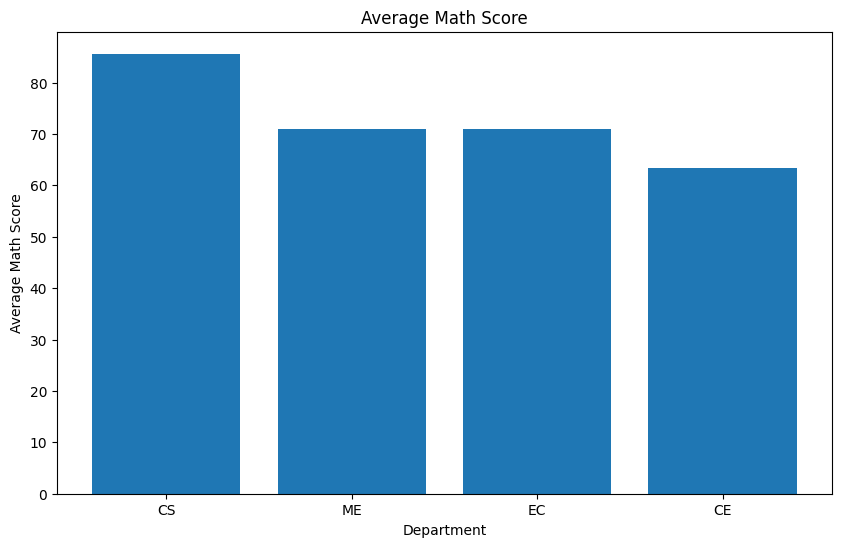

In [29]:
chart1_sql = """
SELECT department,
ROUND(AVG(math_score),2) AS avg_math
FROM students
GROUP BY department
ORDER BY avg_math DESC
"""
chart1_data = pd.read_sql_query(chart1_sql, conn)
fig, ax = plt.subplots(figsize=(10,6))
ax.bar(
    chart1_data['department'],
    chart1_data['avg_math']
)

ax.set_title("Average Math Score")
ax.set_xlabel("Department")
ax.set_ylabel("Average Math Score")

plt.show()

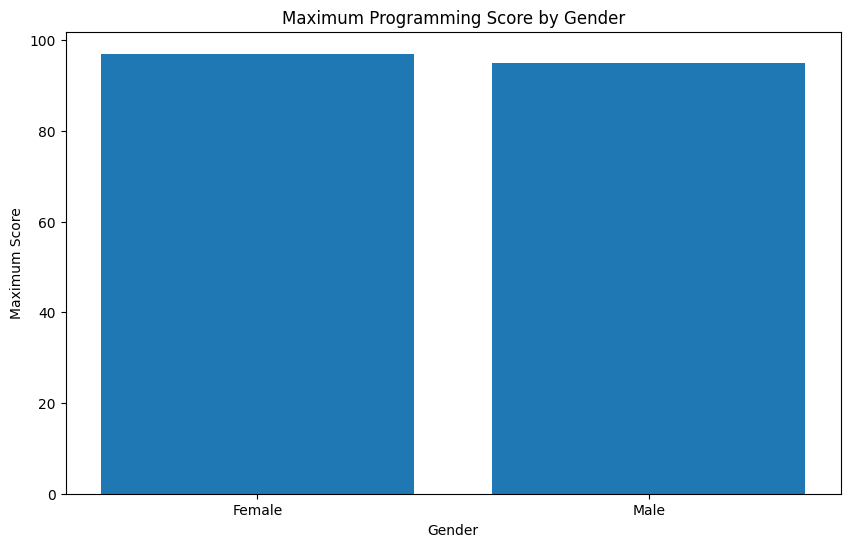

In [35]:
chart1_sql = """
SELECT gender,
MAX(programming_score) AS maxscore
FROM students
GROUP BY gender
ORDER BY maxscore DESC
"""

chart1_data = pd.read_sql_query(chart1_sql, conn)

fig, ax = plt.subplots(figsize=(10,6))

ax.bar(
    chart1_data['gender'],
    chart1_data['maxscore']
)

ax.set_title("Maximum Programming Score by Gender")
ax.set_xlabel("Gender")
ax.set_ylabel("Maximum Score")

plt.show()

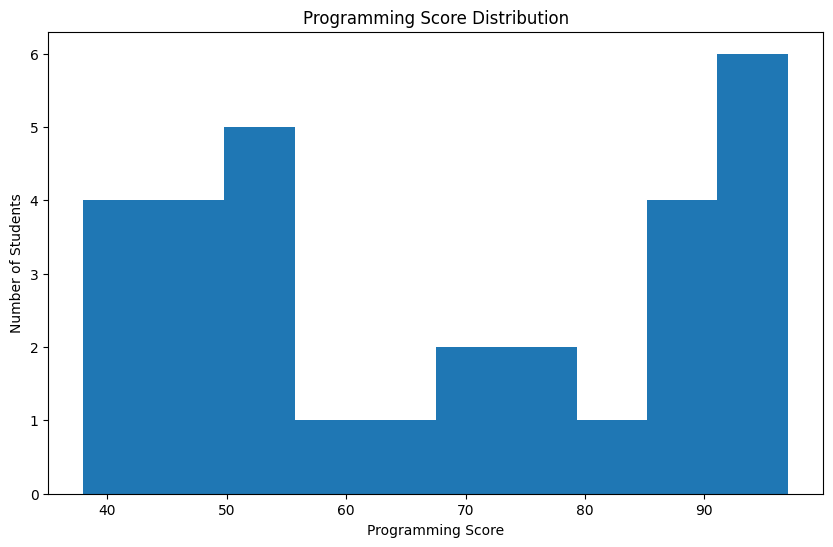

In [36]:
chart1_sql = """
SELECT programming_score
FROM students
"""

chart1_data = pd.read_sql_query(chart1_sql, conn)

fig, ax = plt.subplots(figsize=(10,6))

ax.hist(
    chart1_data['programming_score'],
    bins=10
)

ax.set_title("Programming Score Distribution")
ax.set_xlabel("Programming Score")
ax.set_ylabel("Number of Students")

plt.show()